# 01 · Data overview

First look at the **Sample - Superstore** dataset: shape, schema, types, missing values, duplicates, date coverage and a few sanity checks on the money columns. Everything downstream (EDA, features, forecasting, models) builds on the cleaning done here in `src/data_loader.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_raw, clean, load_clean, data_quality_report
from src.plotting import set_style, savefig
from src.config import TABLE_DIR

set_style()
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

## Raw file

In [2]:
raw = load_raw()
print('raw shape:', raw.shape)
raw.head()

raw shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Cleaned frame

`clean()` parses dates, strips whitespace, drops exact/`Row ID` duplicates and adds `Ship Days`, `Order Year`, `Order Month`.

In [4]:
df = clean(raw)
print('clean shape:', df.shape)
df.head()

clean shape: (9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Ship Days,Order Year,Order Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016,2016-11-01
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016,2016-11-01
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016,2016-06-01
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015,2015-10-01
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015,2015-10-01


In [5]:
df.dtypes.to_frame('dtype')

,dtype
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


## Data-quality report

In [6]:
dq = data_quality_report(df)
dq.to_csv(TABLE_DIR / '01_data_quality.csv', index=False)
dq

,column,dtype,n_null,pct_null,n_unique,sample
0,Row ID,int64,0,0.0,9994,"1, 2, 3"
1,Order ID,object,0,0.0,5009,"CA-2016-152156, CA-2016-138688, US-2015-108966"
2,Order Date,datetime64[ns],0,0.0,1237,"2016-11-08 00:00:00, 2016-06-12 00:00:00, 2015..."
3,Ship Date,datetime64[ns],0,0.0,1334,"2016-11-11 00:00:00, 2016-06-16 00:00:00, 2015..."
4,Ship Mode,object,0,0.0,4,"Second Class, Standard Class, First Class"
5,Customer ID,object,0,0.0,793,"CG-12520, DV-13045, SO-20335"
6,Customer Name,object,0,0.0,793,"Claire Gute, Darrin Van Huff, Sean O'Donnell"
7,Segment,object,0,0.0,3,"Consumer, Corporate, Home Office"
8,Country,object,0,0.0,1,United States
9,City,object,0,0.0,531,"Henderson, Los Angeles, Fort Lauderdale"


### Missing values & duplicates

In [7]:
print('total missing cells :', int(df.isna().sum().sum()))
print('fully duplicate rows :', int(df.duplicated().sum()))
print('duplicate Row IDs    :', int(df['Row ID'].duplicated().sum()))
df.isna().mean().mul(100).round(3).sort_values(ascending=False).head(10)

total missing cells : 0
fully duplicate rows : 0
duplicate Row IDs    : 0


Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
dtype: float64

## Date coverage

In [8]:
print('Order Date:', df['Order Date'].min().date(), '->', df['Order Date'].max().date())
print('Ship  Date:', df['Ship Date'].min().date(), '->', df['Ship Date'].max().date())
print('negative ship days:', int((df['Ship Days'] < 0).sum()))
print('orders (unique Order ID):', df['Order ID'].nunique())
print('customers:', df['Customer ID'].nunique(), '| products:', df['Product ID'].nunique())
df['Order Year'].value_counts().sort_index()

Order Date: 2014-01-03 -> 2017-12-30
Ship  Date: 2014-01-07 -> 2018-01-05
negative ship days: 0
orders (unique Order ID): 5009
customers: 793 | products: 1862


Order Year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64

## Numeric sanity checks

In [9]:
num = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']].describe().T
num['neg_count'] = [(df[c] < 0).sum() for c in num.index]
num

,count,mean,std,min,25%,50%,75%,max,neg_count
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480,0
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000,0
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800,0
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976,1871
Ship Days,9994.0,3.958175,1.747567,0.000,3.00000,4.0000,5.000,7.000,0


C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\01_raw_distributions.png


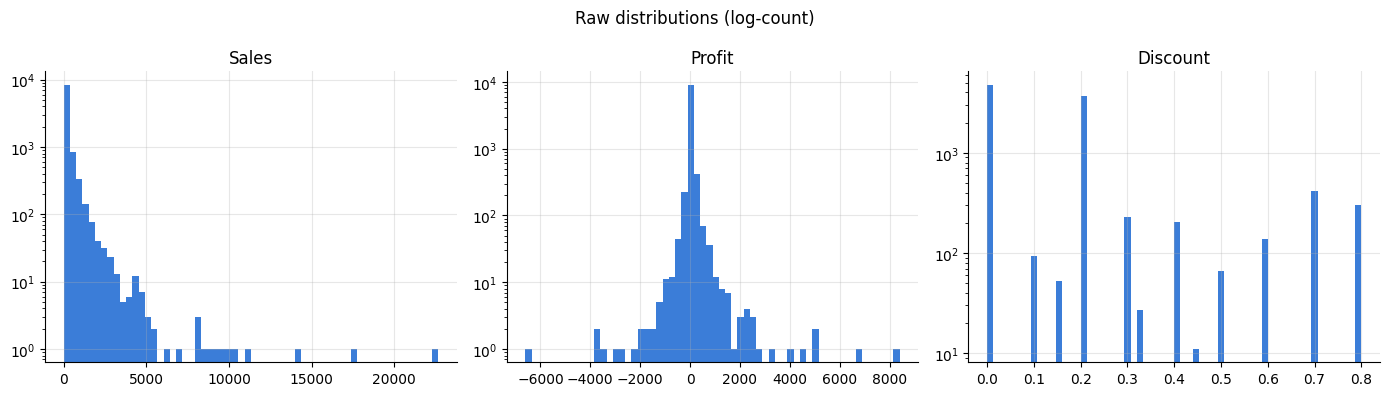

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Sales', 'Profit', 'Discount']):
    ax.hist(df[col], bins=60, color='#3b7dd8')
    ax.set_title(col)
    ax.set_yscale('log')
fig.suptitle('Raw distributions (log-count)')
print(savefig(fig, '01_raw_distributions'))
plt.show()

## Monthly order volume & sales

C:\Users\HP\Documents\Programs\PySpark\EY Training\ml_superstore\outputs\figures\01_monthly_sales_orders.png


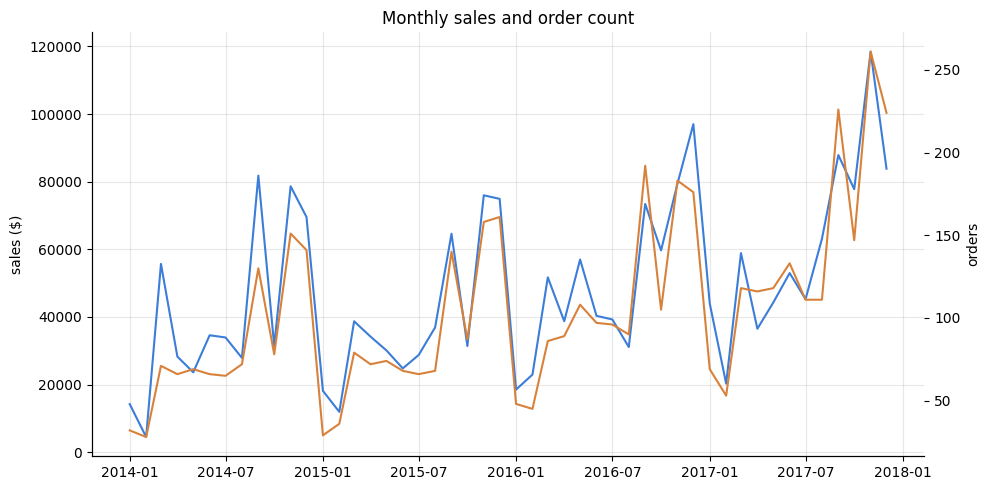

,Order Month,sales,orders,lines,profit
43,2017-08-01,63120.8880,111,218,9040.9557
44,2017-09-01,87866.6520,226,459,10991.5556
45,2017-10-01,77776.9232,147,298,9275.2755
46,2017-11-01,118447.8250,261,459,9690.1037
47,2017-12-01,83829.3188,224,462,8483.3468


In [11]:
monthly = (df.groupby('Order Month')
             .agg(sales=('Sales', 'sum'), orders=('Order ID', 'nunique'),
                  lines=('Row ID', 'size'), profit=('Profit', 'sum'))
             .reset_index())
monthly.to_csv(TABLE_DIR / '01_monthly_summary.csv', index=False)

fig, ax1 = plt.subplots()
ax1.plot(monthly['Order Month'], monthly['sales'], color='#3b7dd8', label='sales')
ax1.set_ylabel('sales ($)')
ax2 = ax1.twinx()
ax2.plot(monthly['Order Month'], monthly['orders'], color='#d8813b', label='orders')
ax2.set_ylabel('orders')
ax2.grid(False)
ax1.set_title('Monthly sales and order count')
print(savefig(fig, '01_monthly_sales_orders'))
plt.show()
monthly.tail()

## Takeaways

- 9,994 order lines, no missing values, no duplicate `Row ID`s.
- Four full years of orders (2014-2017); ship dates land 0-7 days after order date.
- `Sales` and `Profit` are heavily right-skewed; `Profit` has genuine negative values (loss-making lines) — a natural classification target.
- Clear yearly growth and strong Q4 seasonality → good candidate for the forecasting notebook.

Next: `02_eda.ipynb`.